##### ***图论结构***
###### 在计算机科学中，图被广泛用于模拟社交网络（用户是点，好友关系是线）、网页链接（网页是点，超链接是线）、通信网络乃至路径规划等问题。图就像是一张社交网络关系图：<br>1. 节点（顶点）：社交网络中的每个人<br>2. 边：人与人之间的关系（好友、关注等）<br>3. 权重：关系的强度（亲密度、互动频率等）<br>想象一下你所在城市的交通网络：各个地点（如家、学校、商场）是点，连接这些地点的道路是线。图（Graph）就是这种点和线关系的数学抽象，它是用于表示实体间复杂关系的一种数据结构。
###### 相比于其他数据结构，图结构能够自然表达多对多关系，直观表示网络和路径，轻松处理复杂依赖，完美描述网络结构。以下是图的基本术语：
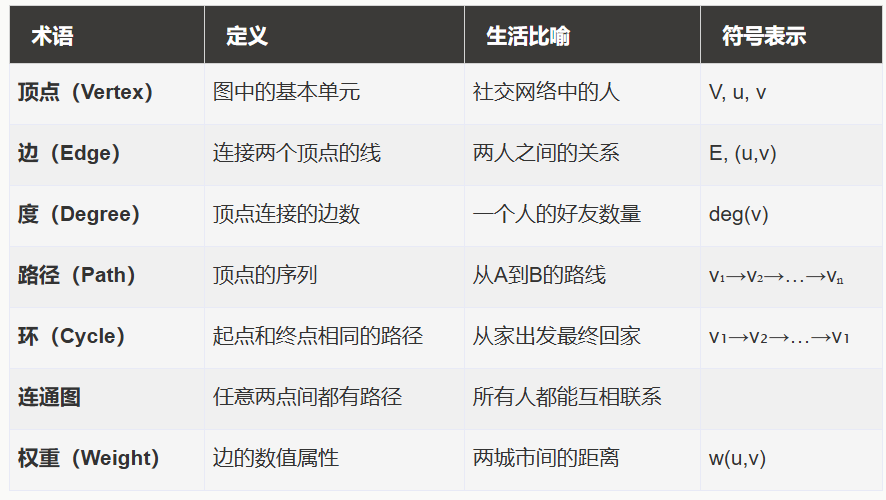
###### 关于图也有众多的分类：
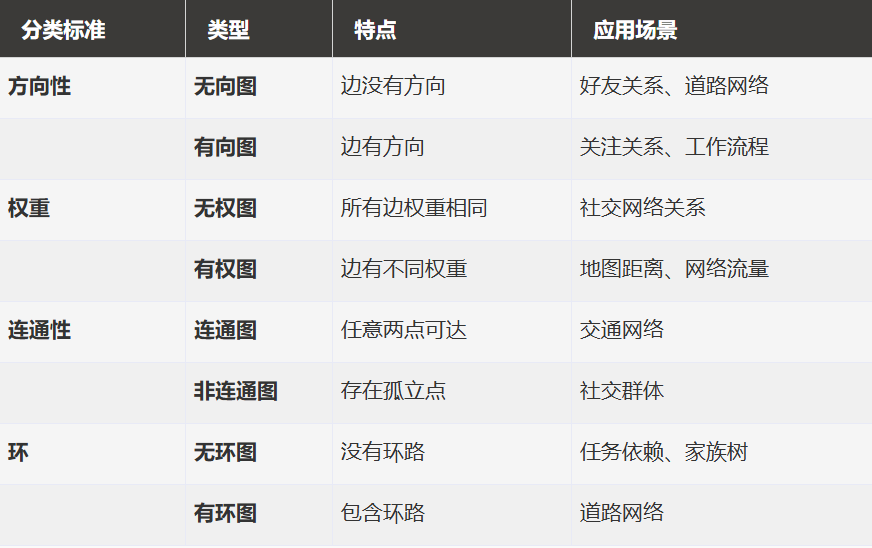


In [1]:
# 接下来利用Python实现一个简单的图
# 一个简单的图示例：用字典表示社交网络好友关系
# 顶点： Alice, Bob, Charlie, Diana
# 边： 表示他们之间的好友关系

social_graph = {
    'Alice': ['Bob', 'Charlie'],
    'Bob': ['Alice', 'Charlie', 'Diana'],
    'Charlie': ['Alice', 'Bob'],
    'Diana': ['Bob']
}
print(f"顶点（用户）: {list(social_graph.keys())}")
print(f"Alice 的好友（边）: {social_graph['Alice']}")

顶点（用户）: ['Alice', 'Bob', 'Charlie', 'Diana']
Alice 的好友（边）: ['Bob', 'Charlie']


In [2]:
# 上述示例的是无权重图，接下来实现一个简单的权重图，即每条边都赋予一个数值
weight_graph = {
    '北京': {('上海', 1200), ('天津', 100)}, # 北京到上海距离1200，到天津距离100
    '上海': {('北京', 1200), ('杭州', 200)},
    '天津': {('北京', 100)},
    '杭州': {('上海', 200)}
}

###### 在这些图中有一些关键术语：<br>1. 度 (Degree): 与一个顶点相连的边的数量。在有向图中，分为入度（指向该顶点的边数）和出度（从该顶点指出的边数）。<br>2. 路径 (Path): 从一个顶点到另一个顶点经过的边序列。如 A -> B -> C。<br>3. 环/回路 (Cycle): 起点和终点是同一个顶点的路径。<br>4. 连通图 (Connected Graph): 在无向图中，任意两个顶点间都存在路径。<br>5. 强连通图 (Strongly Connected Graph): 在有向图中，任意两个顶点间都存在双向路径。
###### 关于图的表示方式，有两种常见的方式：邻接矩阵和邻接表。<br>1. 邻接矩阵即将所有顶点构建成一个二维矩阵来表示点之间的关系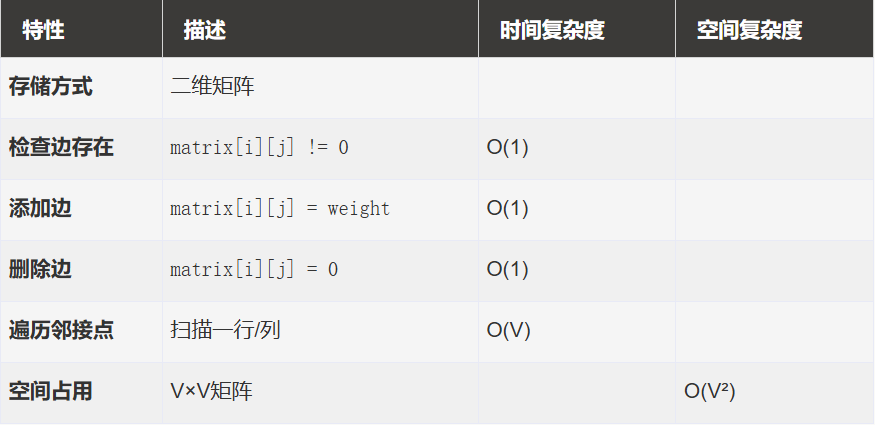<br>2. 邻接表使用带头结点的单链表来代替邻接矩阵的行，对每一个顶点创建一个这样的单链表构成邻接表。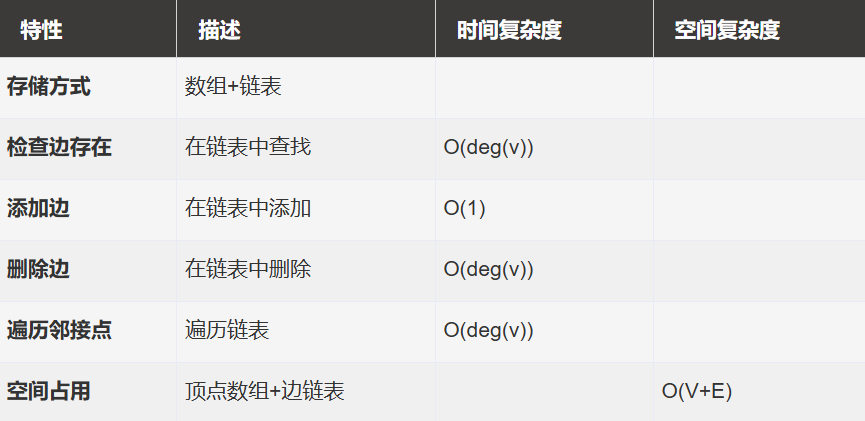

In [ ]:
# 接下来实现利用二维数组实现邻接矩阵
# 顶点： 0-A, 1-B, 2-C
# 边： A-B, A-C
V = 3
adj_matrix = [[0] * V for _ in range(V)]

# 添加边 A-B (0-1)
adj_matrix[0][1] = 1
adj_matrix[1][0] = 1  # 无向图需要设置对称位置
# 添加边 A-C (0-2)
adj_matrix[0][2] = 1
adj_matrix[2][0] = 1

print("邻接矩阵：")
for row in adj_matrix:
    print(row)


邻接矩阵：
[0, 1, 1]
[1, 0, 0]
[1, 0, 0]


In [4]:
# 邻接表为每个顶点维护一个列表（链表， 数组），记录与其直连的所有顶点及权重
adj_list = {
    'A' : ['B', 'C'],
    'B' : ['A'],
    'C' : ['A']
}
print("邻接表：")
for vertex, neighbors in adj_list.items():
    print(f"{vertex}: {neighbors}")

邻接表：
A: ['B', 'C']
B: ['A']
C: ['A']


##### ***图的遍历算法***
###### 遍历是图算法的基础，意味着系统地访问图中的每一个顶点。主要有两种策略：
###### **广度优先搜索**：<br>广度优先搜索（BFS）像"水波扩散"一样，从起点开始，先访问所有直接邻居，再访问邻居的邻居，依此类推。它使用队列来实现。<br>**算法步骤**：<br>1. 将起点放入队列并标记为已访问。<br>2. 当队列不为空时： a. 取出队首顶点 v。 b. 访问 v 的所有未访问邻居，将它们放入队列并标记为已访问。<br>3. 重复步骤2。

In [7]:
from collections import deque
def BFS(graph, start):
    # 使用BFS遍历图，返回访问顺序
    visited = set([start])
    queue = deque([start]) # 初始化队列
    result = [] # 存储访问顺序

    while queue:
        vertex = queue.popleft()
        result.append(vertex) # append操作用于列表（list）
        # 遍历当前节点的邻居
        for neighbor in graph[vertex]:
            if neighbor not in visited:
                visited.add(neighbor) # add操作用于集合（set）
                queue.append(neighbor)
    return result

test_graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

print("BFS 遍历顺序（从A开始）:", BFS(test_graph, 'A'))


BFS 遍历顺序（从A开始）: ['A', 'B', 'C', 'D', 'E', 'F']


###### **深度优先搜索**:<br>深度优先搜索（DFS）像"走迷宫"一样，选择一条路走到尽头，然后回溯，再走另一条路。它使用栈（或递归）来实现。<br>**递归算法步骤**：<br>1. 从顶点 v 开始，标记为已访问。<br>2. 对于 v 的每一个未访问邻居 u： a. 递归调用 DFS(u)。

In [ ]:
def DFS_recursive(graph, vertex, visited=None, result=None):
    # 使用递归实现DFS
    if visited is None:
        visited = set()
    if result is None:
        result = []

    visited.add(vertex)
    result.append(vertex)

    for neighbor in graph[vertex]:
        if neighbor not in visited:
            DFS_recursive(graph, neighbor, visited, result)
    return result

print("DFS 遍历顺序（从A开始）:", DFS_recursive(test_graph, 'A'))